# Implementation

This section demonstrates how to fit a regression model in Python in practice. The two most common packages for fitting regression models in Python are `scikit-learn` and `statsmodels`. Both methods are shown before. 

First, let's import the data and necessary packages. We'll again be using the {doc}`California housing </content/appendix/data>` dataset from `sklearn.datasets`. 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
california = datasets.fetch_california_housing()
X_train = california['data']
y_train = california['target']


## Scikit-Learn

Fitting the model in `scikit-learn` is very similar to how we fit our model from scratch in the previous section. The model is fit in two steps: first instantiate the model and second use the `fit()` method to train it.

In [2]:
from sklearn.linear_model import LinearRegression
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train);

As before, we can plot our fitted values against the true values. To form predictions with the `scikit-learn` model, we can use the `predict` method. Reassuringly, we get the same plot as before. 

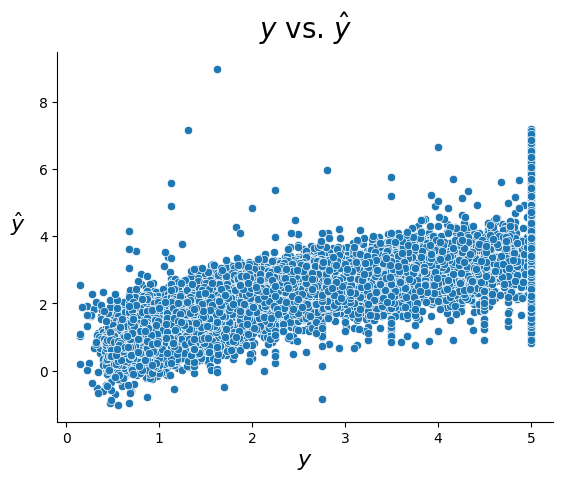

In [3]:
sklearn_predictions = sklearn_model.predict(X_train)
fig, ax = plt.subplots()
sns.scatterplot(x = y_train, y = sklearn_predictions)
ax.set_xlabel(r'$y$', size = 16)
ax.set_ylabel(r'$\hat{y}$', rotation = 0, size = 16, labelpad = 15)
ax.set_title(r'$y$ vs. $\hat{y}$', size = 20, pad = 10)
sns.despine()

We can also check the estimated parameters using the `coef_` attribute as follows (note that only the first few are printed).

In [4]:
predictors = california.feature_names
beta_hats = sklearn_model.coef_
print('\n'.join([f'{predictors[i]}: {round(beta_hats[i], 3)}' for i in range(3)]))

MedInc: 0.437
HouseAge: 0.009
AveRooms: -0.107


## Statsmodels

`statsmodels` is another package frequently used for running linear regression in Python. There are two ways to run regression in `statsmodels`. The first uses `numpy` arrays like we did in the previous section. An example is given below.

```{note}
Note two subtle differences between this model and the models we've previously built. First, we have to manually add a constant to the predictor dataframe in order to give our model an intercept term. Second, we supply the training data when *instantiating* the model, rather than when fitting it. 
```

In [7]:
import statsmodels.api as sm

X_train_with_constant = sm.add_constant(X_train)
sm_model1 = sm.OLS(y_train, X_train_with_constant)
sm_fit1 = sm_model1.fit()
sm_predictions1 = sm_fit1.predict(X_train_with_constant)

The second way to run regression in `statsmodels` is with `R`-style formulas and `pandas` dataframes. This allows us to identify predictors and target variables by name. An example is given below.

In [ ]:
import pandas as pd
from IPython.display import display

df = pd.DataFrame(X_train, columns = california['feature_names'])
df['target'] = y_train
display(df.head())

formula = 'target ~ ' + ' + '.join(california['feature_names'])
print('formula:', formula)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


formula: target ~ MedInc + HouseAge + AveRooms + AveBedrms + Population + AveOccup + Latitude + Longitude


In [9]:
import statsmodels.formula.api as smf

sm_model2 = smf.ols(formula, data = df)
sm_fit2 = sm_model2.fit()
sm_predictions2 = sm_fit2.predict(df)